<a href="https://colab.research.google.com/github/kmshamsulfahad/license-plate-recognition/blob/main/license_plate_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


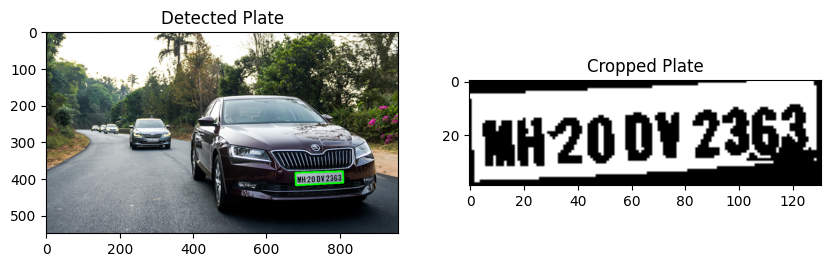

✅ Detected License Plate Number: wH20 DY 2363)



In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: Install libraries
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python matplotlib

# STEP 3: Import libraries
import cv2
import pytesseract
import matplotlib.pyplot as plt

# STEP 4: Give path from Google Drive
image_path = '/content/drive/MyDrive/skoda-india-front-license-plate.jpg'

# Read image
img = cv2.imread(image_path)

if img is None:
    print("Image not found. Check Drive path!")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise reduction
    gray = cv2.bilateralFilter(gray, 11, 17, 17)

    # Edge detection
    edged = cv2.Canny(gray, 30, 200)

    # Find contours
    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    screenCnt = None

    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.018 * peri, True)

        if len(approx) == 4:
            screenCnt = approx
            break

    if screenCnt is None:
        print("❌ No license plate detected")
    else:
        cv2.drawContours(img, [screenCnt], -1, (0,255,0), 3)

        x, y, w, h = cv2.boundingRect(screenCnt)
        plate = gray[y:y+h, x:x+w]

        plate = cv2.threshold(plate, 150, 255, cv2.THRESH_BINARY)[1]

        text = pytesseract.image_to_string(plate, config='--psm 8')

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Detected Plate")

        plt.subplot(1,2,2)
        plt.imshow(plate, cmap='gray')
        plt.title("Cropped Plate")

        plt.show()

        print("✅ Detected License Plate Number:", text)